## PRACTICA OBLIGATORIA: **Introducción Keras**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de modelado del dataset del titanic empleando y comparando dos modelos diferentes. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


## Descripción de la práctica

En esta práctica el objetivo es jugar con el framework de [Keras](https://www.tensorflow.org/guide/keras) a partir de la construcción de un modelo DL sobre MLP para clasificar imagenes de ropa como camisetas, zapatos y zapatillas deportivas.

Vamos a utilizar el set de datos de [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist)
que contiene mas de 70,000 imagenes en 10 categorias. Las imagenes muestran articulos individuales de ropa a una resolucion baja (28 por 28 pixeles)

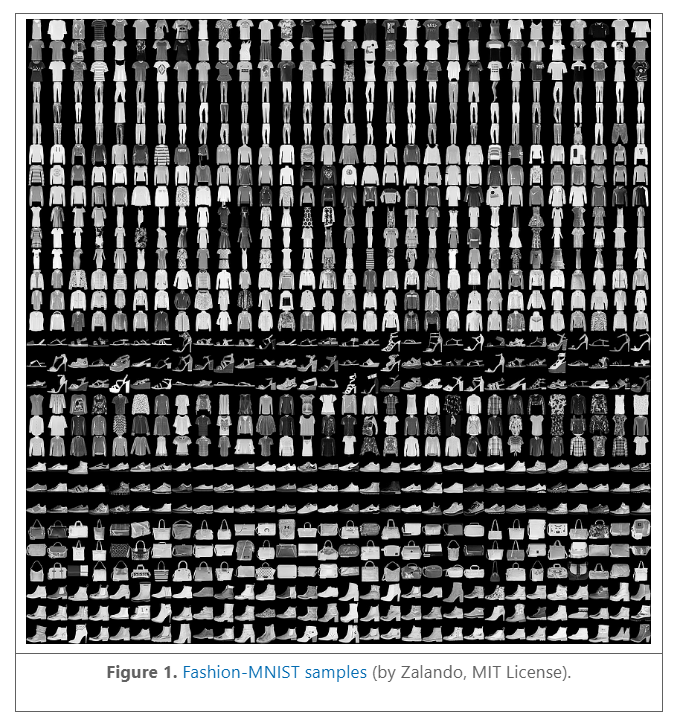

La *class* de ropa que la imagen representa:

<table>
  <tr>
    <th>Label</th>
    <th>Class</th>
  </tr>
  <tr>
    <td>0</td>
    <td>T-shirt/top</td>
  </tr>
  <tr>
    <td>1</td>
    <td>Trouser</td>
  </tr>
    <tr>
    <td>2</td>
    <td>Pullover</td>
  </tr>
    <tr>
    <td>3</td>
    <td>Dress</td>
  </tr>
    <tr>
    <td>4</td>
    <td>Coat</td>
  </tr>
    <tr>
    <td>5</td>
    <td>Sandal</td>
  </tr>
    <tr>
    <td>6</td>
    <td>Shirt</td>
  </tr>
    <tr>
    <td>7</td>
    <td>Sneaker</td>
  </tr>
    <tr>
    <td>8</td>
    <td>Bag</td>
  </tr>
    <tr>
    <td>9</td>
    <td>Ankle boot</td>
  </tr>
</table>

Cada imagen es mapeada a una unica etiqueta. Ya que los *Class names* no estan incluidos en el dataset, es recomendable construirse una lista o un diccionario que permita mapear la clase a el tipo literal.

Se pide:

0. Cargar el dataset desde TensorFlow (tienes una celda ya proporcionada para hacerlo) y visualiza al menos 5 instancias, se recomienda crear una función que permita visualizar subsets de instancias con su etiqueta adecuada. 

1. Construir un modelo DL basado en MLP, es decir una red densa que clasifique las imágenes de ropa. No vas a necesitar más de 1 o 2 capas ocultas. Recuerda que es un problema de clasificación multiclase para configurar correctamente la capa de salida en número de neuronas y función de activiación. Ten en cuenta también que necesitarás utilizar una capa que aplane las imágenes o bien convertir el dataset por tu cuenta.

2. No crees un set de validación, especifica en el entrenamiento que emplee un 20% del dataset en validación. Además muestra gráficamente la evolución en el entrenamiento de la pérdida (loss) por un lado (del conjuto de train y del de validación) y la evolución de la métrica escogida (también de train  y de validación). Razona si es conveniente tener un "callback" de earlystopping, y, en cualquier caso, implementa uno.

3. Finalmente evalua contra test. Muestra el report de clasificación y haz un análisis de los resultados. Para ello, muestra algunas predicciones, el nivel de confianza y si era acertada o no, además muestra la matriz de confusión y analiza en que tipos se confunde más y con que otra clase lo confunde. 

Ejemplo del grafico de predicción más nivel de confianza:

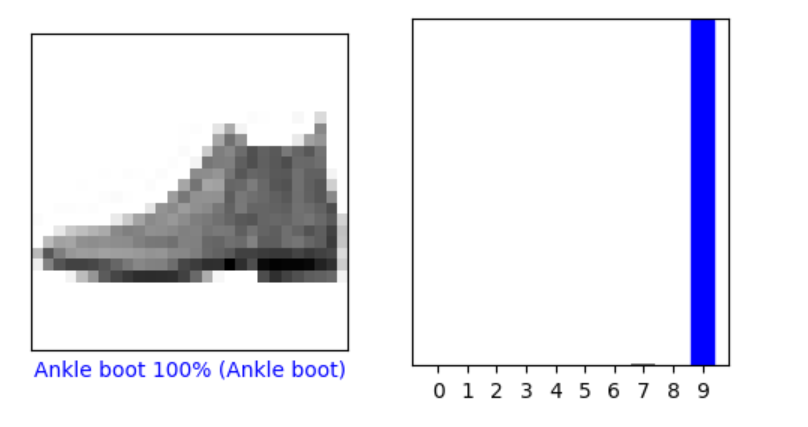

Fíjate que el gráfico de la derecha muestra la probabilidad por clase, de forma que cuanto más alta la probabilidad de la clase elegida más confianza podemos decir que tiene en el resultado. 

**EXTRA**: Como parte extra, obtén los errores de clasificación en los que la confianza del modelo sobre su clasificación errónea supere el 0.7 o 70% (es decir los errores en los que la probabilidad de la clase elegida, equivocadamente, fuera igual o superior a 0.7), de existir muéstralos y analiza si son de alguna clase específica.

```python

# Cargar FASHION_MNIST

fashion_mnist = keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

```

In [2]:
fashion_mnist = keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Definimos las etiquetas de texto correspondientes a los números 0-9
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [4]:
def visualizar_instancias(imagenes, etiquetas, clases, num_imagenes=5):
    """
    Muestra un subset de imágenes con su etiqueta correspondiente.
    
    Parámetros:
    - imagenes: Array de numpy con las imágenes (ej. train_images)
    - etiquetas: Array de numpy con los índices de las etiquetas (ej. train_labels)
    - clases: Lista de strings con los nombres de las clases (class_names)
    - num_imagenes: Número de imágenes a mostrar (por defecto 5)
    """
    plt.figure(figsize=(10, 2)) # Ajusta el tamaño según necesites
    
    for i in range(num_imagenes):
        plt.subplot(1, num_imagenes, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        
        # Mostramos la imagen. El cmap binary es típico para este dataset en escala de grises
        plt.imshow(imagenes[i], cmap=plt.cm.binary)
        
        # Añadimos la etiqueta real debajo de la imagen
        indice_etiqueta = etiquetas[i]
        plt.xlabel(clases[indice_etiqueta])
        
    plt.show()

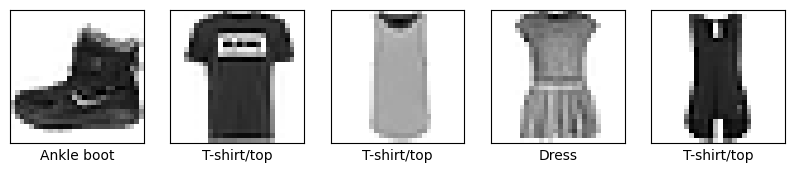

In [5]:
# Visualizamos las primeras 5 imágenes del set de entrenamiento
visualizar_instancias(train_images, train_labels, class_names, num_imagenes=5)

In [6]:
model = keras.Sequential([
    # 1. Capa de entrada (Aplanado): Transforma la matriz 2D (28x28) en un vector 1D (784 pixeles)
    keras.layers.Flatten(input_shape=(28, 28)),
    
    # 2. Capa oculta: Densa con activación ReLU (128 neuronas es un estándar habitual)
    # El enunciado sugiere no usar más de 1 o 2 capas ocultas
    keras.layers.Dense(128, activation='relu'),
    
    # 3. Capa de salida: CONFIGURACIÓN CRÍTICA PARA MULTICLASE
    # - 10 neuronas: Una por cada clase de ropa (Camisetas, Zapatos, etc.)
    # - Activación Softmax: Para obtener la probabilidad de pertenencia a cada clase
    keras.layers.Dense(10, activation='softmax')
])

h:\RepoBootcamp\RepoEjercicios\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6853 - loss: 4.4789 - val_accuracy: 0.7116 - val_loss: 0.7665
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7139 - loss: 0.7130 - val_accuracy: 0.7328 - val_loss: 0.6489
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7679 - loss: 0.6169 - val_accuracy: 0.7886 - val_loss: 0.5659
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7981 - loss: 0.5726 - val_accuracy: 0.8053 - val_loss: 0.5787
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8142 - loss: 0.5375 - val_accuracy: 0.8177 - val_loss: 0.5548
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8246 - loss: 0.5119 - val_accuracy: 0.8048 - val_loss: 0.5561
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8325 - loss: 0.4992 - val_accuracy: 0.8156 - val_loss: 0.5547
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8316 - loss: 0.4987 - 

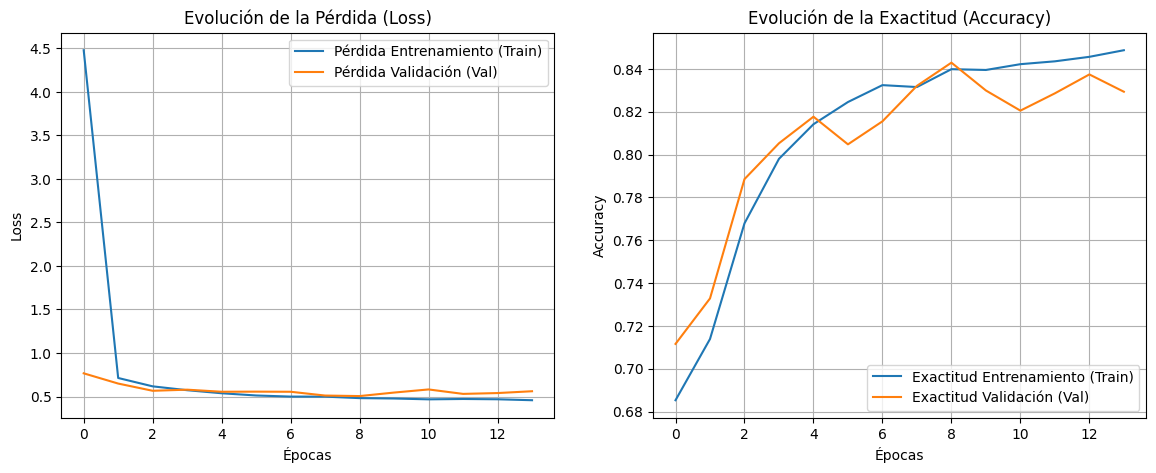

In [8]:
# 1. Definimos el Callback de EarlyStopping
# 'patience=3': Si tras 3 épocas no mejora, para.
# 'restore_best_weights=True': Al acabar, vuelve a cargar los pesos de la mejor época (fundamental).
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

# 2. Entrenamos el modelo
# validation_split=0.2 separa automáticamente el 20% final de los datos para validar
history = model.fit(
    train_images, 
    train_labels, 
    epochs=50,  # Ponemos un número alto y dejamos que el callback corte cuando sea necesario
    validation_split=0.2, 
    callbacks=[early_stopping]
)

# 3. Visualización de resultados
# Convertimos el historial a un DataFrame de Pandas para facilitarnos la vida
historial_df = pd.DataFrame(history.history)

# Creamos una figura con dos gráficas (Loss y Accuracy)
plt.figure(figsize=(14, 5))

# Gráfica de Pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(historial_df['loss'], label='Pérdida Entrenamiento (Train)')
plt.plot(historial_df['val_loss'], label='Pérdida Validación (Val)')
plt.title('Evolución de la Pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Gráfica de Exactitud (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(historial_df['accuracy'], label='Exactitud Entrenamiento (Train)')
plt.plot(historial_df['val_accuracy'], label='Exactitud Validación (Val)')
plt.title('Evolución de la Exactitud (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 516us/step
--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

 T-shirt/top       0.73      0.86      0.79      1000
     Trouser       0.99      0.92      0.96      1000
    Pullover       0.62      0.79      0.70      1000
       Dress       0.82      0.86      0.84      1000
        Coat       0.72      0.78      0.75      1000
      Sandal       0.94      0.91      0.93      1000
       Shirt       0.75      0.40      0.52      1000
     Sneaker       0.90      0.94      0.92      1000
         Bag       0.97      0.94      0.95      1000
  Ankle boot       0.94      0.93      0.93      1000

    accuracy                           0.83     10000
   macro avg       0.84      0.83      0.83     10000
weighted avg       0.84      0.83      0.83     10000



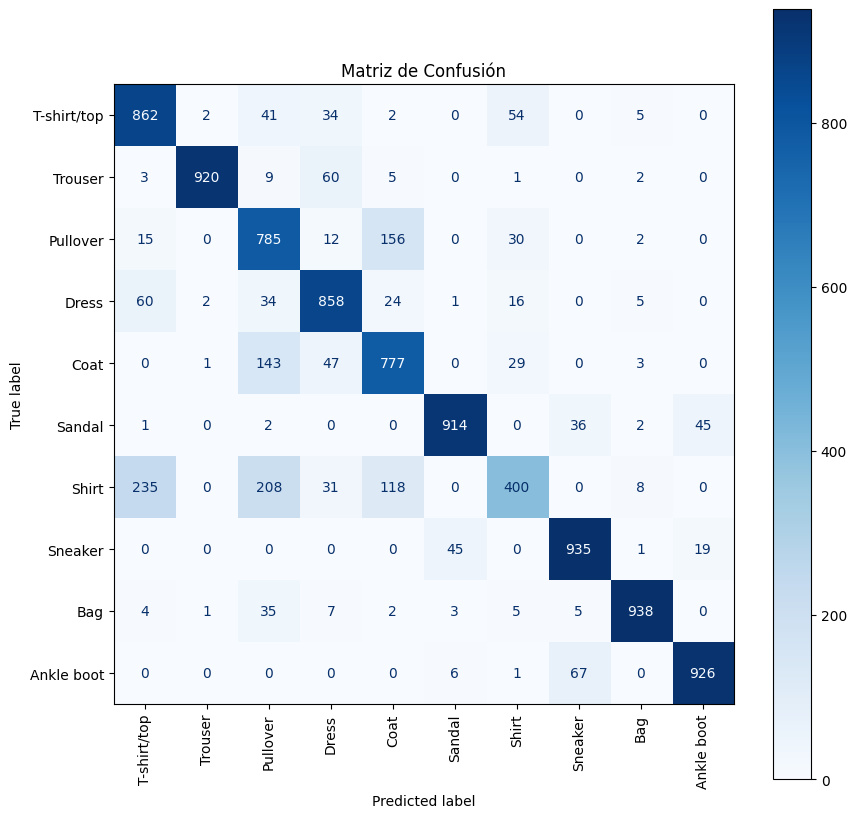

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Obtener las predicciones sobre el set de test
# model.predict devuelve un array de probabilidades (10 por imagen)
predictions = model.predict(test_images)

# Nos quedamos con la clase que tenga mayor probabilidad (argmax)
pred_labels = np.argmax(predictions, axis=1)

# 2. Imprimir el Classification Report
print("--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(test_labels, pred_labels, target_names=class_names))

# 3. Generar y visualizar la Matriz de Confusión
fig, ax = plt.subplots(figsize=(10, 10))
cm = confusion_matrix(test_labels, pred_labels)

# Usamos ConfusionMatrixDisplay para un gráfico limpio y estándar
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')

plt.title("Matriz de Confusión")
plt.show()

In [13]:
def plot_image(i, predictions_array, true_label, img):
  # CORRECCIÓN AQUÍ: Añadimos [i] a predictions_array
  predictions_array, true_label, img = predictions_array[i], true_label[i], img[i]
  
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  # CORRECCIÓN AQUÍ: También añadimos [i] a predictions_array
  predictions_array, true_label = predictions_array[i], true_label[i]
  
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

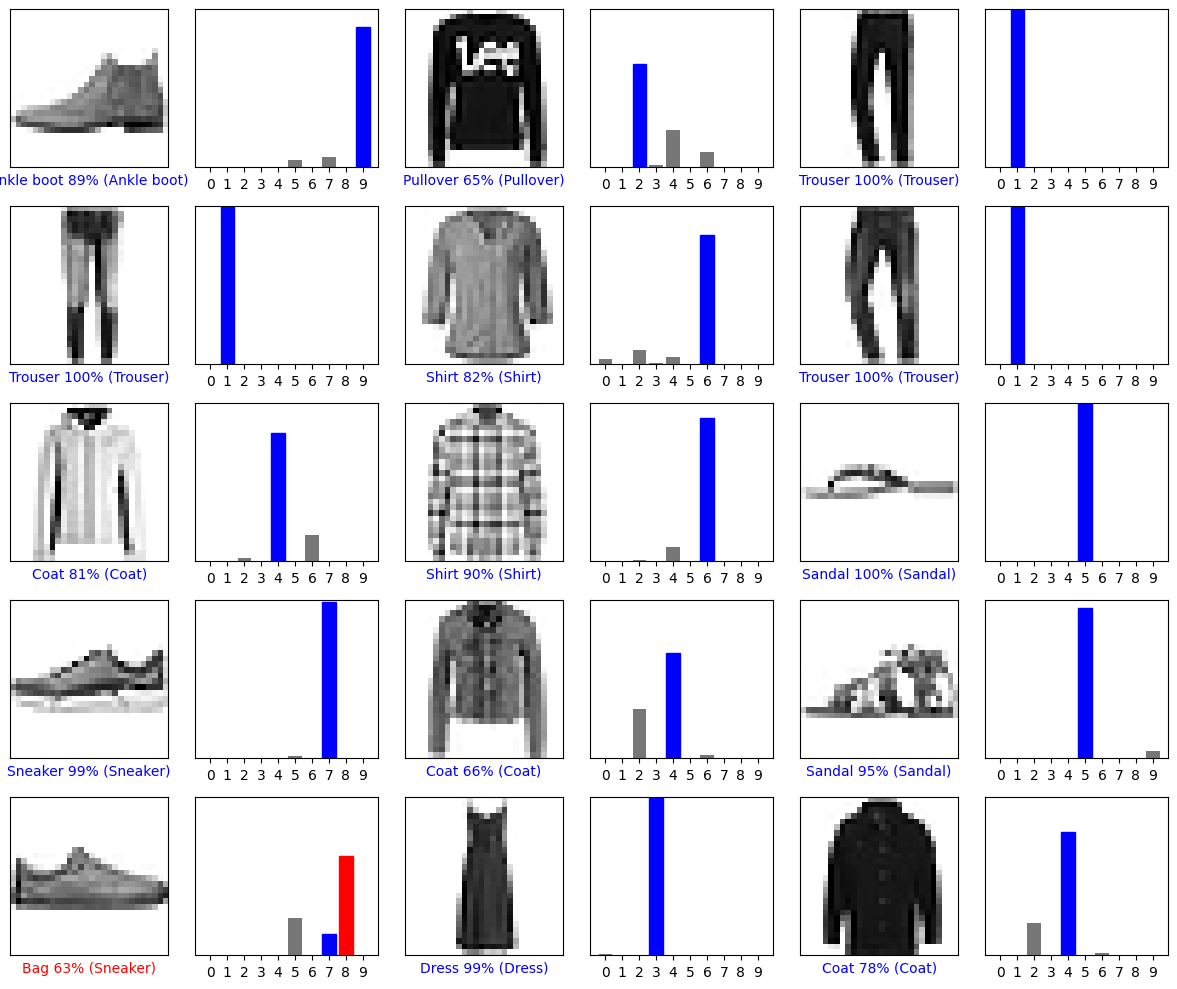

In [14]:
# --- EJECUCIÓN VISUAL ---
num_rows = 5
num_cols = 3
num_images = num_rows * num_cols

plt.figure(figsize=(2*2*num_cols, 2*num_rows))

for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i, predictions, test_labels, test_images)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i, predictions, test_labels)

plt.tight_layout()
plt.show()

Se han encontrado 667 errores con confianza > 70%.


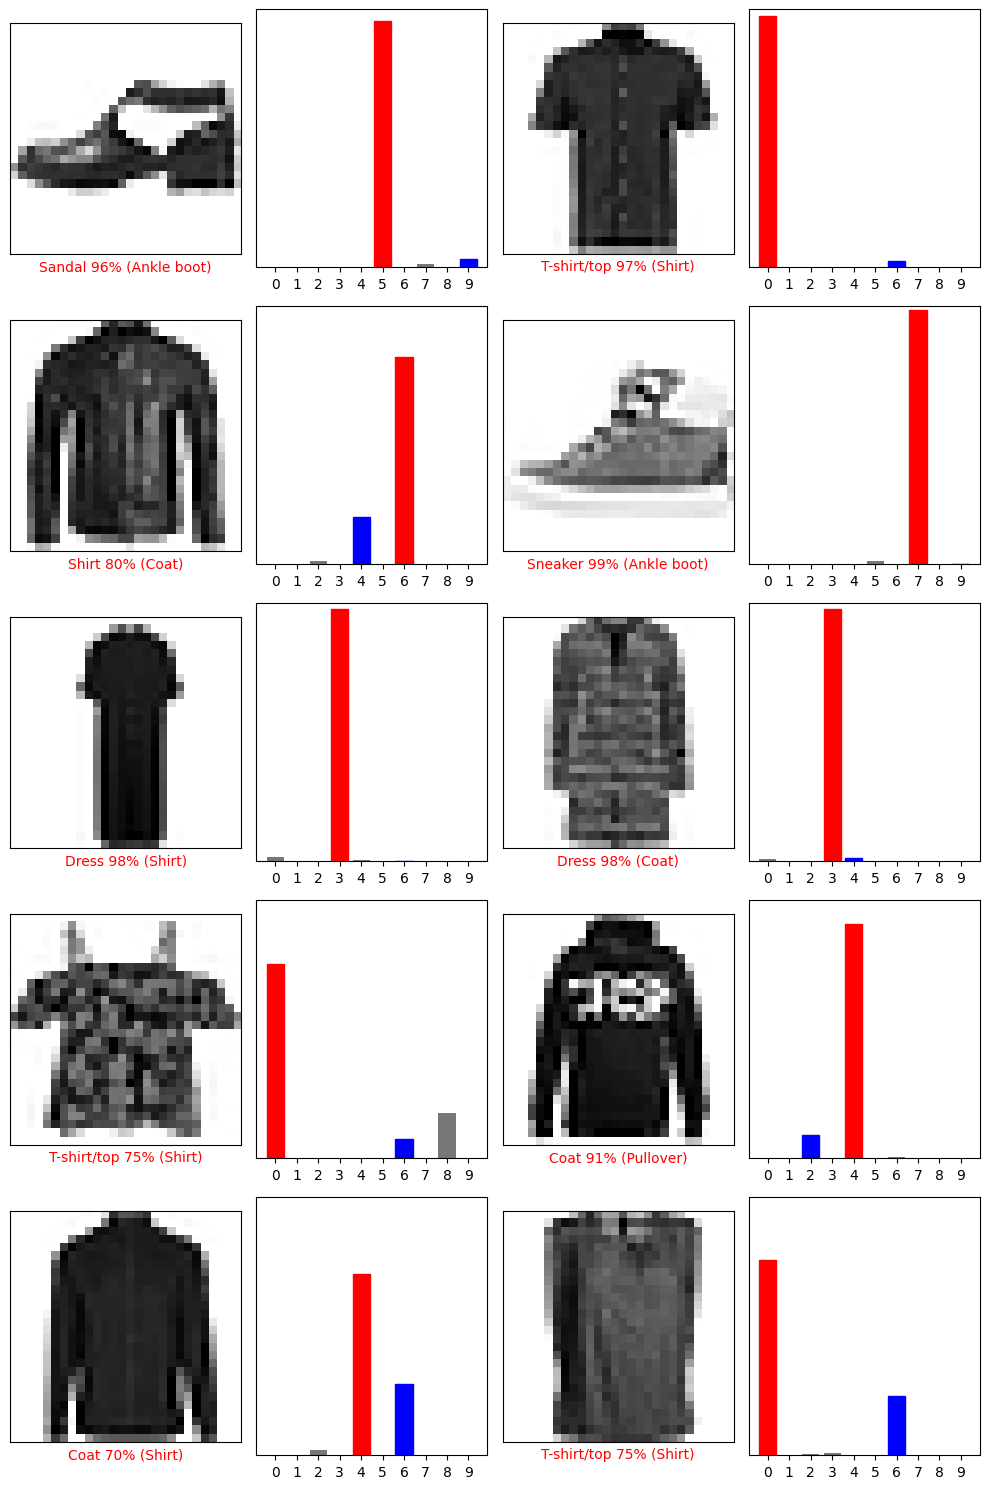

In [15]:
# 1. Filtramos los índices donde hay error Y alta confianza
indices_errores_graves = []

for i in range(len(test_labels)):
    pred_label = np.argmax(predictions[i])
    true_label = test_labels[i]
    confianza = np.max(predictions[i])
    
    # Condición del enunciado: Error Y Confianza >= 0.7
    if pred_label != true_label and confianza >= 0.7:
        indices_errores_graves.append(i)

print(f"Se han encontrado {len(indices_errores_graves)} errores con confianza > 70%.")

# 2. Visualizamos hasta 10 de estos errores
num_mostrar = min(10, len(indices_errores_graves))

if num_mostrar > 0:
    num_rows = (num_mostrar + 1) // 2  # Calculamos filas necesarias
    num_cols = 2 # Mostraremos 2 por fila para verlos grandes
    
    plt.figure(figsize=(10, 3 * num_rows))
    
    for i in range(num_mostrar):
        # Obtenemos el índice real dentro del dataset de test
        idx = indices_errores_graves[i]
        
        plt.subplot(num_rows, 2*num_cols, 2*i+1)
        plot_image(idx, predictions, test_labels, test_images)
        
        plt.subplot(num_rows, 2*num_cols, 2*i+2)
        plot_value_array(idx, predictions, test_labels)
        
    plt.tight_layout()
    plt.show()
else:
    print("¡Sorprendente! Tu modelo no tiene errores de alta confianza.")